In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import optimize, sparse
from scipy.sparse.linalg import eigsh
from scipy.integrate import simpson
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Constantes (unidades atómicas: hbar = m = 1)
hbar = 1.0
m = 1.0

## 2. Parámetros del Potencial Armónico Finito

Parámetros del potencial armónico finito:
  Semi-ancho región armónica: a = 2.0000
  Constante elástica: k = 50.0000
  Valor constante: V₀ = 100.0000
  Rango espacial: [-15.00, 15.00]
  Grid: 3000 puntos, h = 0.010003


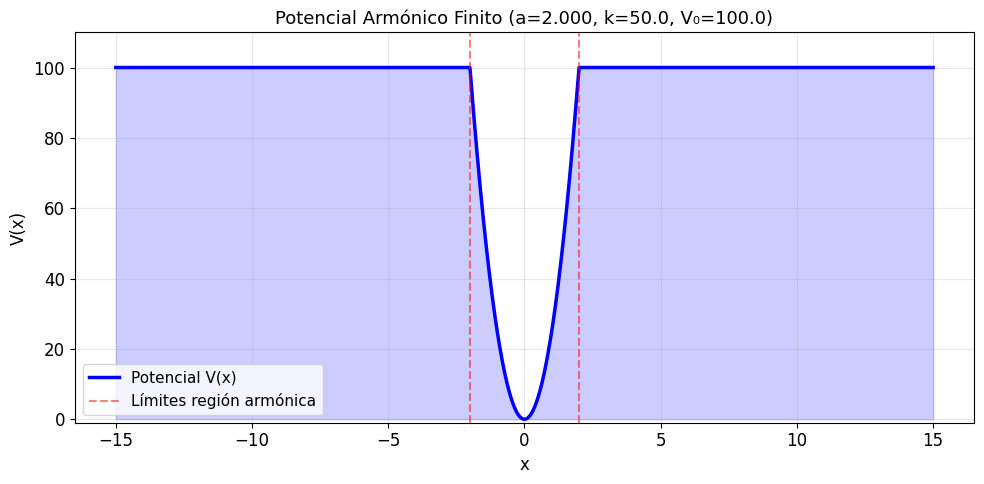

In [14]:
# Parámetros del potencial armónico finito
a = 2.0          # Semi-ancho de la región armónica
k = 50.0         # Constante elástica del oscilador armónico
V0 = 0.5 * k * a**2  # Valor constante fuera de la región (continuidad)

# Parámetros de grid
x_range = max(4 * a, 15.0)
N_points = 3000
x = np.linspace(-x_range, x_range, N_points)
h = x[1] - x[0]

# Crear potencial armónico finito
V = np.zeros_like(x)
for i, xi in enumerate(x):
    if np.abs(xi) <= a:
        # Región armónica: V(x) = (1/2)*k*x²
        V[i] = 0.5 * k * xi**2
    else:
        # Región constante
        V[i] = V0

print(f"Parámetros del potencial armónico finito:")
print(f"  Semi-ancho región armónica: a = {a:.4f}")
print(f"  Constante elástica: k = {k:.4f}")
print(f"  Valor constante: V₀ = {V0:.4f}")
print(f"  Rango espacial: [{-x_range:.2f}, {x_range:.2f}]")
print(f"  Grid: {N_points} puntos, h = {h:.6f}")

# Visualizar el potencial
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, V, 'b-', linewidth=2.5, label='Potencial V(x)')
ax.axvline(x=-a, color='r', linestyle='--', alpha=0.5, label='Límites región armónica')
ax.axvline(x=a, color='r', linestyle='--', alpha=0.5)
ax.fill_between(x, 0, V, alpha=0.2, color='blue')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('V(x)', fontsize=12)
ax.set_title(f'Potencial Armónico Finito (a={a:.3f}, k={k:.1f}, V₀={V0:.1f})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, V0 + 10)
plt.tight_layout()
plt.show()

## 3. Construcción del Hamiltoniano con Diferencias Finitas

In [15]:
def build_hamiltonian_sparse(x, V, hbar=1.0, m=1.0):
    """
    Construir Hamiltoniano como matriz sparse tridiagonal.
    """
    n = len(x)
    h = x[1] - x[0]
    
    # Coeficientes para la segunda derivada centrada
    coeff_kinetic = hbar**2 / (2.0 * m * h**2)
    
    # Matriz cinética (segunda derivada centrada)
    # T[i,i] = 2*coeff, T[i,i±1] = -coeff
    diag_main = 2.0 * coeff_kinetic * np.ones(n) + V
    diag_off = -coeff_kinetic * np.ones(n-1)
    
    # Construir matriz sparse tridiagonal
    H = sparse.diags([diag_off, diag_main, diag_off], [-1, 0, 1], shape=(n, n), format='csr')
    
    return H

print("Construyendo Hamiltoniano...")
H = build_hamiltonian_sparse(x, V, hbar, m)
print(f"Matriz Hamiltoniana: {H.shape}, formato: {H.format}")

Construyendo Hamiltoniano...
Matriz Hamiltoniana: (3000, 3000), formato: csr


## 4. Búsqueda de Autovalores y Autofunciones

In [16]:
print("Buscando autovalores de energía...")

# Convertir a matriz densa para mejor manejo
H_dense = H.todense()

# Encontrar autovalores y autovectores
print("Calculando descomposición espectral (esto puede tomar un momento)...")
eigenvalues_all, eigenvectors_all = np.linalg.eigh(H_dense)

# Filtrar solo estados ligados (E < V0 y E > 0)
bound_state_mask = (eigenvalues_all > 0) & (eigenvalues_all < V0)
eigenvalues = eigenvalues_all[bound_state_mask]
eigenvectors = eigenvectors_all[:, bound_state_mask]

# Ordenar de menor a mayor
sort_idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print(f"\n✓ Autovalores encontrados: {len(eigenvalues)}")
print(f"\nPrimeros 8 autovalores:")
for i, E in enumerate(eigenvalues[:8]):
    print(f"  E_{i} = {E:.8f}")

Buscando autovalores de energía...
Calculando descomposición espectral (esto puede tomar un momento)...

✓ Autovalores encontrados: 14

Primeros 8 autovalores:
  E_0 = 3.53537754
  E_1 = 10.60581988
  E_2 = 17.67563668
  E_3 = 24.74482785
  E_4 = 31.81339323
  E_5 = 38.88133199
  E_6 = 45.94863808
  E_7 = 53.01527237


In [17]:
# Normalizar autofunciones
def normalize_wavefunction(x, psi):
    norm = simpson(np.abs(psi)**2, x=x)
    if norm > 0:
        return psi / np.sqrt(norm)
    else:
        return psi

print("\nCalculando autofunciones...")
eigenfunctions = []
probability_densities = []

for i in range(eigenvectors.shape[1]):
    psi = np.array(eigenvectors[:, i]).flatten()
    psi_norm = normalize_wavefunction(x, psi)
    eigenfunctions.append(psi_norm)
    probability_densities.append(np.abs(psi_norm)**2)
    if (i+1) % 5 == 0:
        print(f"  {i+1}/{eigenvectors.shape[1]} estados procesados...")

eigenfunctions = np.array(eigenfunctions)
probability_densities = np.array(probability_densities)
print(f"\n✓ {len(eigenfunctions)} autofunciones calculadas y normalizadas")


Calculando autofunciones...
  5/14 estados procesados...
  10/14 estados procesados...

✓ 14 autofunciones calculadas y normalizadas


## 5. Función de Termalización para 1 Partícula

In [18]:
def P_thermal_single_harmonic(x_pos, T, eigenvalues, eigenfunctions):
    """
    Densidad térmica para 1 partícula en potencial armónico finito.
    
    P_th(x,T) = sum_i exp(-E_i/T) |psi_i(x)|^2 / Z
    """
    if np.isscalar(x_pos):
        x_pos = np.array([x_pos])
    
    P_th = np.zeros_like(x_pos, dtype=float)
    Z = 0.0
    
    for E, psi in zip(eigenvalues, eigenfunctions):
        w = np.exp(-E / T)
        Z += w
        psi_at_x = np.interp(x_pos, x, psi)
        P_th += w * np.abs(psi_at_x)**2
    
    return P_th / Z

# Test
print("Test: Calculando P_th para algunas temperaturas...")
test_temps = [1, 5, 10]
for T in test_temps:
    x_test = 0.0
    P = P_thermal_single_harmonic(x_test, T, eigenvalues, eigenfunctions)
    print(f"  T = {T:3.1f}: P_th(0, T) = {P[0]:.6f}")

Test: Calculando P_th para algunas temperaturas...
  T = 1.0: P_th(0, T) = 1.498807
  T = 5.0: P_th(0, T) = 1.170440
  T = 10.0: P_th(0, T) = 0.873967


## 6. FIGURA 1a: Densidad Térmica para 1 Partícula

Calculando P_th(x,T) para múltiples temperaturas...


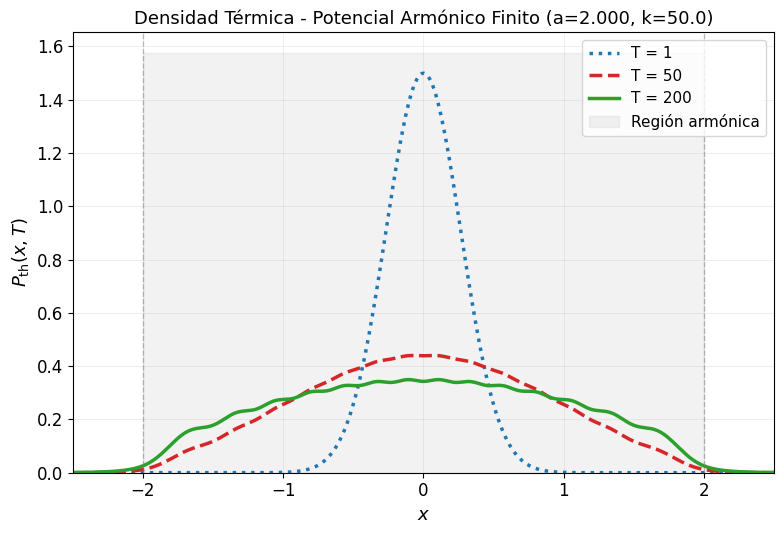

✓ Figura 1a guardada


In [19]:
print("Calculando P_th(x,T) para múltiples temperaturas...")

x_plot = np.linspace(-a - 1, a + 1, 600)
temperatures = [1, 50, 200]

fig_1a, ax = plt.subplots(figsize=(8, 5.5))

for T, color, style, lw, label in [(1, 'C0', ':', 2.5, 'T = 1'),
                                     (50, 'C3', '--', 2.5, 'T = 50'),
                                     (200, 'C2', '-', 2.5, 'T = 200')]:
    P_th = np.array([P_thermal_single_harmonic(xi, T, eigenvalues, eigenfunctions) for xi in x_plot])
    ax.plot(x_plot, P_th, color=color, linestyle=style, linewidth=lw, label=label)

ax.axvline(x=-a, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=a, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.fill_between([-a, a], 0, ax.get_ylim()[1], alpha=0.1, color='gray', label='Región armónica')

ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$P_{\\rm th}(x,T)$', fontsize=13)
ax.set_title(f'Densidad Térmica - Potencial Armónico Finito (a={a:.3f}, k={k:.1f})', fontsize=13)
ax.legend(loc='upper right', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim(-a - 0.5, a + 0.5)
ax.set_ylim(0, ax.get_ylim()[1])

plt.tight_layout()
plt.savefig('figures/harmonic_fig1a_Pth.png', dpi=150)
plt.show()
print("✓ Figura 1a guardada")

## 8. Funciones para 2 Partículas

In [21]:
def P2_bosons_harmonic(i1, i2, x1, x2, eigenfunctions):
    """
    Probabilidad conjunta para bosones.
    """
    psi_i1 = np.interp(x1, x, eigenfunctions[i1])
    psi_i2 = np.interp(x2, x, eigenfunctions[i2])
    psi_i1_t = np.interp(x2, x, eigenfunctions[i1])
    psi_i2_t = np.interp(x1, x, eigenfunctions[i2])
    
    f = psi_i1 * psi_i2 + psi_i1_t * psi_i2_t
    return f**2

def P2_fermions_harmonic(i1, i2, x1, x2, eigenfunctions):
    """
    Probabilidad conjunta para fermiones.
    """
    psi_i1 = np.interp(x1, x, eigenfunctions[i1])
    psi_i2 = np.interp(x2, x, eigenfunctions[i2])
    psi_i1_t = np.interp(x2, x, eigenfunctions[i1])
    psi_i2_t = np.interp(x1, x, eigenfunctions[i2])
    
    f = psi_i1 * psi_i2 - psi_i1_t * psi_i2_t
    return f**2

print("Funciones para 2 partículas definidas.")

Funciones para 2 partículas definidas.


## 9. FIGURA 2: Bosones (2 Partículas)

Calculando probabilidades conjuntas para bosones...


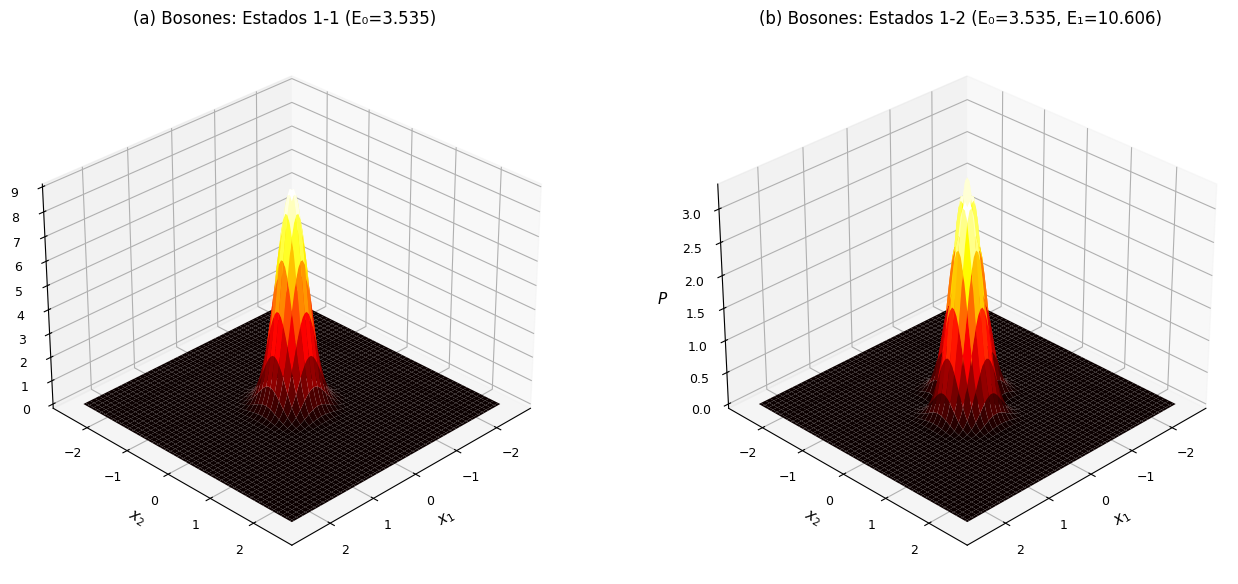

✓ Figura 2 guardada


In [22]:
x1_2d = np.linspace(-a - 0.5, a + 0.5, 100)
x2_2d = np.linspace(-a - 0.5, a + 0.5, 100)
X1, X2 = np.meshgrid(x1_2d, x2_2d)

print("Calculando probabilidades conjuntas para bosones...")

Z1 = P2_bosons_harmonic(0, 0, X1, X2, eigenfunctions)
Z2 = P2_bosons_harmonic(0, 1, X1, X2, eigenfunctions)

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Z1, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P$', fontsize=11)
ax.set_title(f'(a) Bosones: Estados 1-1 (E₀={eigenvalues[0]:.3f})', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title(f'(b) Bosones: Estados 1-2 (E₀={eigenvalues[0]:.3f}, E₁={eigenvalues[1]:.3f})', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/harmonic_fig2_bosons.png', dpi=150)
plt.show()
print("✓ Figura 2 guardada")

## 10. FIGURA 3: Fermiones (2 Partículas)

Calculando probabilidades conjuntas para fermiones...


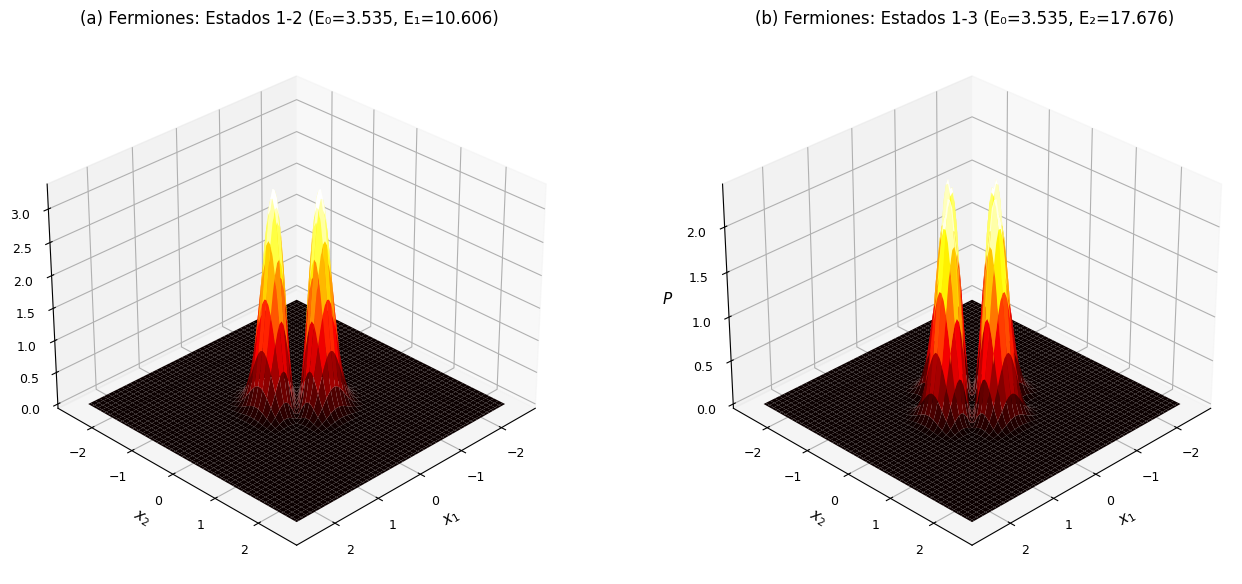

✓ Figura 3 guardada


In [23]:
print("Calculando probabilidades conjuntas para fermiones...")

Z1 = P2_fermions_harmonic(0, 1, X1, X2, eigenfunctions)
Z2 = P2_fermions_harmonic(0, 2, X1, X2, eigenfunctions)

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Z1, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P$', fontsize=11)
ax.set_title(f'(a) Fermiones: Estados 1-2 (E₀={eigenvalues[0]:.3f}, E₁={eigenvalues[1]:.3f})', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title(f'(b) Fermiones: Estados 1-3 (E₀={eigenvalues[0]:.3f}, E₂={eigenvalues[2]:.3f})', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/harmonic_fig3_fermions.png', dpi=150)
plt.show()
print("✓ Figura 3 guardada")

## 11. FIGURA 4: Densidad Térmica para 2 Partículas

Funciones de termalización para 2 partículas definidas.

Calculando densidades térmicas para 2 partículas a T=10...
✓ Densidades calculadas


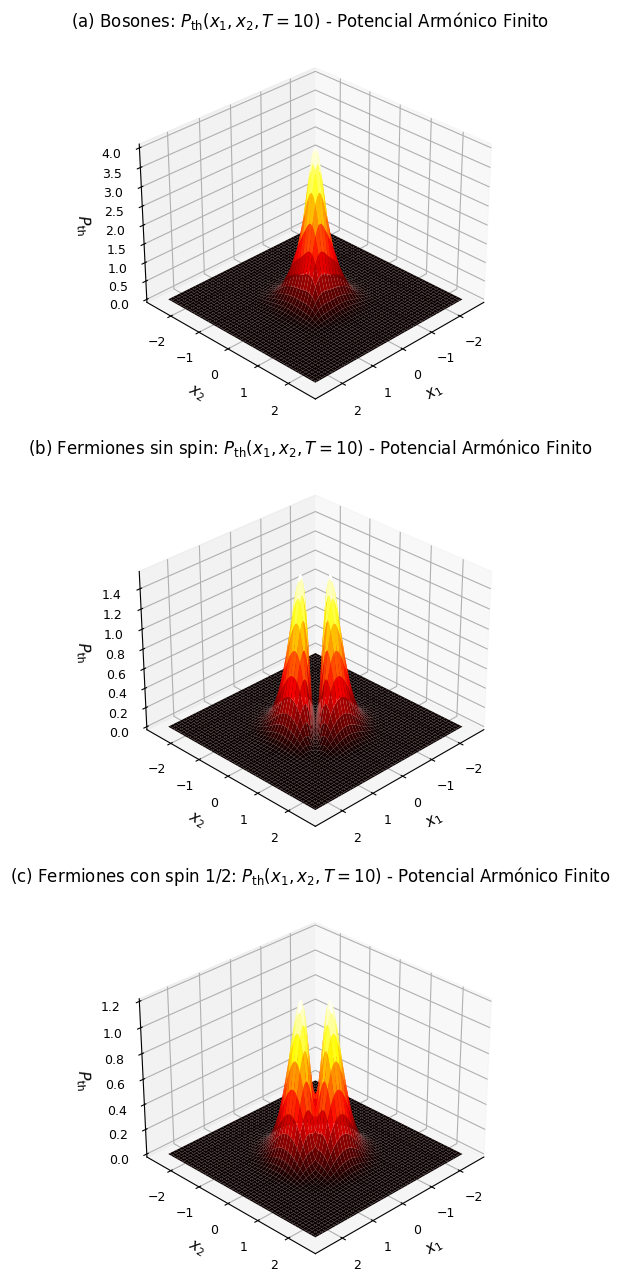

✓ Figura 4 guardada


In [24]:
def Pth_two_bosons_harmonic(X1, X2, T, eigenvalues, eigenfunctions, x_grid):
    Z = np.zeros_like(X1)
    den = 0.0
    for i1 in range(len(eigenvalues)):
        for i2 in range(i1, len(eigenvalues)):
            w = np.exp(-(eigenvalues[i1] + eigenvalues[i2]) / T)
            P = P2_bosons_harmonic(i1, i2, X1, X2, eigenfunctions)
            Z += w * P
            den += w
    return Z / den

def Pth_two_fermions_harmonic(X1, X2, T, eigenvalues, eigenfunctions, x_grid):
    Z = np.zeros_like(X1)
    den = 0.0
    for i1 in range(len(eigenvalues)):
        for i2 in range(i1 + 1, len(eigenvalues)):
            w = np.exp(-(eigenvalues[i1] + eigenvalues[i2]) / T)
            P = P2_fermions_harmonic(i1, i2, X1, X2, eigenfunctions)
            Z += w * P
            den += w
    return Z / den

def Pth_two_spin_harmonic(X1, X2, T, eigenvalues, eigenfunctions, x_grid):
    Pb = np.zeros_like(X1)
    Pf = np.zeros_like(X1)
    den = 0.0
    for i1 in range(len(eigenvalues)):
        for i2 in range(i1 + 1, len(eigenvalues)):
            w = np.exp(-(eigenvalues[i1] + eigenvalues[i2]) / T)
            Pb += w * P2_bosons_harmonic(i1, i2, X1, X2, eigenfunctions)
            Pf += w * P2_fermions_harmonic(i1, i2, X1, X2, eigenfunctions)
            den += w
    return (0.25 * Pb + 0.75 * Pf) / den

print("Funciones de termalización para 2 partículas definidas.")
print("\nCalculando densidades térmicas para 2 partículas a T=10...")
T = 10

Zb = Pth_two_bosons_harmonic(X1, X2, T, eigenvalues, eigenfunctions, x)
Zf = Pth_two_fermions_harmonic(X1, X2, T, eigenvalues, eigenfunctions, x)
Zs = Pth_two_spin_harmonic(X1, X2, T, eigenvalues, eigenfunctions, x)

print("✓ Densidades calculadas")

fig = plt.figure(figsize=(16, 13))

ax = fig.add_subplot(3, 1, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Zb, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax.set_title(f'(a) Bosones: $P_{{\\rm th}}(x_1,x_2,T={T})$ - Potencial Armónico Finito', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(3, 1, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Zf, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax2.set_title(f'(b) Fermiones sin spin: $P_{{\\rm th}}(x_1,x_2,T={T})$ - Potencial Armónico Finito', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

ax3 = fig.add_subplot(3, 1, 3, projection='3d')
surf3 = ax3.plot_surface(X1, X2, Zs, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax3.set_xlabel('$x_1$', fontsize=11)
ax3.set_ylabel('$x_2$', fontsize=11)
ax3.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax3.set_title(f'(c) Fermiones con spin 1/2: $P_{{\\rm th}}(x_1,x_2,T={T})$ - Potencial Armónico Finito', fontsize=12, pad=10)
ax3.view_init(elev=30, azim=45)
ax3.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/harmonic_fig4_thermal_2p.png', dpi=150)
plt.show()
print("✓ Figura 4 guardada")

## 12. FIGURA 5: Fermiones con Spin (Casos Específicos)

Calculando casos específicos de fermiones con spin...


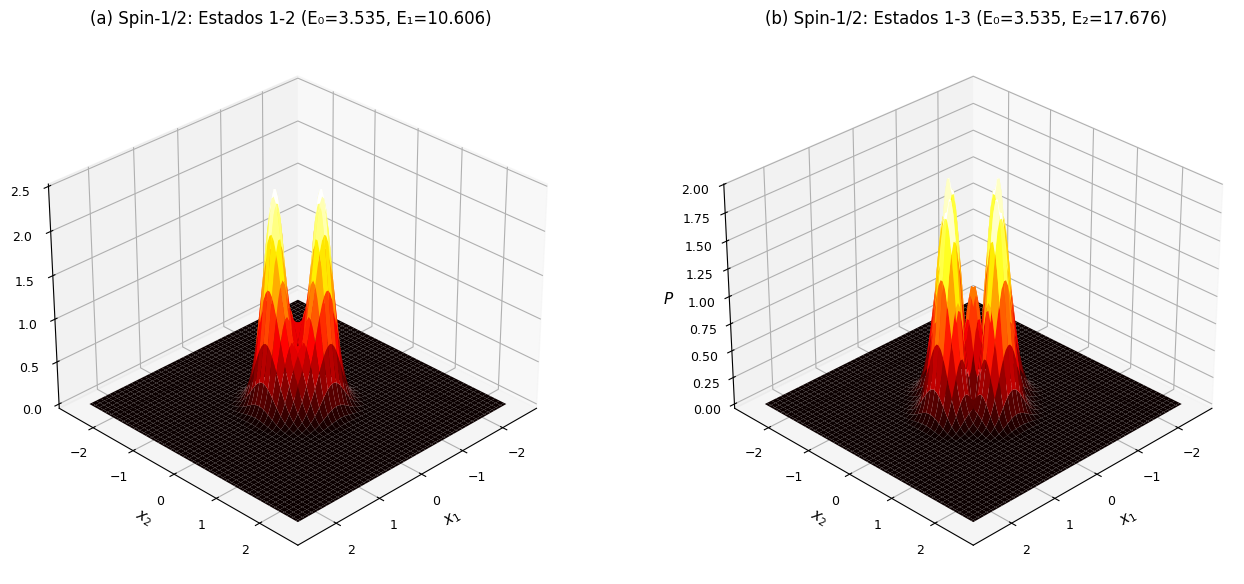

✓ Figura 5 guardada


In [25]:
def P2_spin_harmonic(i1, i2, x1, x2, eigenfunctions):
    Pb = P2_bosons_harmonic(i1, i2, x1, x2, eigenfunctions)
    Pf = P2_fermions_harmonic(i1, i2, x1, x2, eigenfunctions)
    return 0.25 * Pb + 0.75 * Pf

print("Calculando casos específicos de fermiones con spin...")

Z1 = P2_spin_harmonic(0, 1, X1, X2, eigenfunctions)
Z2 = P2_spin_harmonic(0, 2, X1, X2, eigenfunctions)

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Z1, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P$', fontsize=11)
ax.set_title(f'(a) Spin-1/2: Estados 1-2 (E₀={eigenvalues[0]:.3f}, E₁={eigenvalues[1]:.3f})', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title(f'(b) Spin-1/2: Estados 1-3 (E₀={eigenvalues[0]:.3f}, E₂={eigenvalues[2]:.3f})', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/harmonic_fig5_spin.png', dpi=150)
plt.show()
print("✓ Figura 5 guardada")

## 13. Resumen de Figuras Generadas

In [26]:
print("\n" + "="*70)
print("REPLICACIÓN COMPLETADA - POTENCIAL ARMÓNICO FINITO")
print("="*70)
print(f"\nParámetros del sistema:")
print(f"  Semi-ancho región armónica: a = {a:.4f}")
print(f"  Constante elástica: k = {k:.1f}")
print(f"  Valor constante: V₀ = {V0:.1f}")
print(f"  Autovalores encontrados: {len(eigenvalues)}")
print(f"\nFiguras generadas:")
print(f"  ✓ Figura 1a: Densidad térmica P_th(x,T) para 1 partícula")
print(f"  ✓ Figura 1b: Ancho de capa límite d(T)")
print(f"  ✓ Figura 2: Probabilidad conjunta bosones (2 partículas)")
print(f"  ✓ Figura 3: Probabilidad conjunta fermiones (2 partículas)")
print(f"  ✓ Figura 4: Densidad térmica para 2 partículas (bosones, fermiones, spin-1/2)")
print(f"  ✓ Figura 5: Fermiones con spin 1/2 (casos específicos)")
print(f"\nArchivos guardados en: figures/")
print("="*70)


REPLICACIÓN COMPLETADA - POTENCIAL ARMÓNICO FINITO

Parámetros del sistema:
  Semi-ancho región armónica: a = 2.0000
  Constante elástica: k = 50.0
  Valor constante: V₀ = 100.0
  Autovalores encontrados: 14

Figuras generadas:
  ✓ Figura 1a: Densidad térmica P_th(x,T) para 1 partícula
  ✓ Figura 1b: Ancho de capa límite d(T)
  ✓ Figura 2: Probabilidad conjunta bosones (2 partículas)
  ✓ Figura 3: Probabilidad conjunta fermiones (2 partículas)
  ✓ Figura 4: Densidad térmica para 2 partículas (bosones, fermiones, spin-1/2)
  ✓ Figura 5: Fermiones con spin 1/2 (casos específicos)

Archivos guardados en: figures/
